In [1]:
# loading the libraries
import pandas as pd

# Setup plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# Data Dictionary & Evaluation Metrics

### Relevant Data Fields
| Field Name | Description |
| :--- | :--- |
| **`sessionId`** | Unique anonymous identifier for each participant. |
| **`familiarity`** | The participant's self-reported expertise/familiarity with reading or writing poetry. |
| **`comparison_type`** | The specific prompt strategies being pitted against each other (e.g., *Baseline_vs_Guideline*). |
| **`theme`** | The emotional context of the generated poems (*Grief*, *Hope*, *Longing*). |
| **`[metric]_selected_condition`** | The actual AI prompt strategy (*Baseline*, *Guideline*, *Persona*) that the participant chose as the winner for that specific question. (Values like *TIE*, *BOTH*, *NEITHER*, or *NOT_SURE* indicate uncertainty). |

---

### Evaluation Criteria Definitions
In the context of this study, participants evaluated each poem pair across the following metrics:
1. **Stronger Overall:** Which poem the participant judged as the better poem overall, considering all aspects of quality together?
2. **Emotional Impact:** Which poem evokes a deeper, more profound, or more resonant emotional response from the reader?
3. **Originality:** Which poem uses the most unique, creative, and non-cliché language, metaphors, and imagery?
4. **Like / Endorse:** Which poem does the participant subjectively prefer the most on a personal level?
5. **Human Authorship (Bonus):** A Turing-test metric evaluating which poem the reader logically perceives as genuinely human-written, regardless of its objective quality.


In [2]:
# loading the data
data = pd.read_csv('poetry_study_2026-04-01.csv')

# dropping irrelevant columns
cols_to_drop = [
    'emotional_impact_answer',
    'originality_answer',
    'like_answer',
    'human_authorship_answer',

    # time fields
    'timestamp',
    'completedAt'
]

data = data.drop(columns=cols_to_drop)

data.sample(n=10)

,sessionId,familiarity,comparisonId,comparison_type,theme,poemA_id,poemB_id,original_condition_A,original_condition_B,displayed_left_poem_id,...,stronger_overall_selected_poem_id,stronger_overall_selected_condition,emotional_impact_selected_poem_id,emotional_impact_selected_condition,originality_selected_poem_id,originality_selected_condition,like_selected_poem_id,like_selected_condition,human_authorship_selected_poem_id,human_authorship_selected_condition
87,sess_s9g2eue4_1774187671674,very_familiar,comp-31,Baseline_vs_Guideline,Hope,Hope-Baseline-1,Hope-Guideline-1,Baseline,Guideline,Hope-Guideline-1,...,Hope-Baseline-1,Baseline,Hope-Baseline-1,Baseline,Hope-Baseline-1,Baseline,Hope-Baseline-1,Baseline,Hope-Baseline-1,Baseline
74,sess_rzepk1a9_1774289816769,very_familiar,comp-11,Guideline_vs_Persona,Longing,Longing-Guideline-1,Longing-Persona-1,Guideline,Persona,Longing-Guideline-1,...,Longing-Persona-1,Persona,Longing-Persona-1,Persona,Longing-Persona-1,Persona,Longing-Persona-1,Persona,Longing-Persona-1,Persona
85,sess_s9g2eue4_1774187671674,very_familiar,comp-19,Baseline_vs_Guideline,Grief,Grief-Baseline-4,Grief-Guideline-4,Baseline,Guideline,Grief-Guideline-4,...,Grief-Guideline-4,Guideline,Grief-Guideline-4,Guideline,Grief-Baseline-4,Baseline,BOTH,BOTH,Grief-Baseline-4,Baseline
15,sess_6pv7xrd7_1773820732658,very_familiar,comp-07,Baseline_vs_Persona,Longing,Longing-Baseline-2,Longing-Persona-2,Baseline,Persona,Longing-Persona-2,...,Longing-Baseline-2,Baseline,BOTH,BOTH,Longing-Baseline-2,Baseline,Longing-Baseline-2,Baseline,Longing-Baseline-2,Baseline
28,sess_banls1ei_1774530996506,somewhat_familiar,comp-26,Guideline_vs_Persona,Grief,Grief-Guideline-1,Grief-Persona-1,Guideline,Persona,Grief-Persona-1,...,Grief-Guideline-1,Guideline,Grief-Guideline-1,Guideline,Grief-Guideline-1,Guideline,Grief-Guideline-1,Guideline,Grief-Guideline-1,Guideline
14,sess_6pv7xrd7_1773820732658,very_familiar,comp-25,Baseline_vs_Persona,Grief,Grief-Baseline-5,Grief-Persona-5,Baseline,Persona,Grief-Baseline-5,...,Grief-Baseline-5,Baseline,Grief-Baseline-5,Baseline,NOT_SURE,NOT_SURE,Grief-Baseline-5,Baseline,Grief-Baseline-5,Baseline
73,sess_rzepk1a9_1774289816769,very_familiar,comp-44,Guideline_vs_Persona,Hope,Hope-Guideline-4,Hope-Persona-4,Guideline,Persona,Hope-Guideline-4,...,Hope-Guideline-4,Guideline,Hope-Guideline-4,Guideline,Hope-Guideline-4,Guideline,Hope-Guideline-4,Guideline,Hope-Guideline-4,Guideline
70,sess_n5baf3fo_1773740926289,very_familiar,comp-31,Baseline_vs_Guideline,Hope,Hope-Baseline-1,Hope-Guideline-1,Baseline,Guideline,Hope-Baseline-1,...,NaN,NaN,NOT_SURE,NOT_SURE,NOT_SURE,NOT_SURE,BOTH,BOTH,NOT_SURE,NOT_SURE
68,sess_n5baf3fo_1773740926289,very_familiar,comp-24,Baseline_vs_Persona,Grief,Grief-Baseline-4,Grief-Persona-4,Baseline,Persona,Grief-Baseline-4,...,NaN,NaN,NOT_SURE,NOT_SURE,NOT_SURE,NOT_SURE,BOTH,BOTH,NOT_SURE,NOT_SURE
82,sess_s9g2eue4_1774187671674,very_familiar,comp-12,Guideline_vs_Persona,Longing,Longing-Guideline-2,Longing-Persona-2,Guideline,Persona,Longing-Persona-2,...,Longing-Persona-2,Persona,Longing-Guideline-2,Guideline,Longing-Persona-2,Persona,Longing-Persona-2,Persona,Longing-Persona-2,Persona


In [3]:
# checking missing values
data.isna().sum()

sessionId                               0
familiarity                             0
comparisonId                            0
comparison_type                         0
theme                                   0
poemA_id                                0
poemB_id                                0
original_condition_A                    0
original_condition_B                    0
displayed_left_poem_id                  0
displayed_right_poem_id                 0
displayed_left_condition                0
displayed_right_condition               0
stronger_overall_answer                 0
stronger_overall_selected_poem_id      15
stronger_overall_selected_condition    15
emotional_impact_selected_poem_id       0
emotional_impact_selected_condition     0
originality_selected_poem_id            0
originality_selected_condition          0
like_selected_poem_id                   0
like_selected_condition                 0
human_authorship_selected_poem_id       0
human_authorship_selected_conditio

In [4]:
# We simply fill NaN with 'TIE' to match the 'BOTH'/'NEITHER' pattern.
data['stronger_overall_selected_condition'] = data['stronger_overall_selected_condition'].fillna('TIE')
data['stronger_overall_selected_poem_id'] = data['stronger_overall_selected_poem_id'].fillna('TIE')

In [ ]:
# Prose -> Poetry

# - 

# INSIGHTS FROM RESULTS

## Participant Overview & Descriptives


In [5]:
# Set aesthetic style
sns.set_theme(style="whitegrid", context="talk")
palette = {'Baseline': '#95a5a6', 'Guideline': '#2ecc71', 'Persona': '#e74c3c', 'TIE': '#bdc3c7', 'BOTH': '#34495e', 'NEITHER': '#95a5a6', 'NOT_SURE': '#ecf0f1'}

In [6]:
# Participant Overview
unique_participants = data['sessionId'].nunique()
total_responses = len(data)

print(f"Total Unique Participants: {unique_participants}")
print(f"Total Responses: {total_responses}")
print(f"Responses per Participant (Sanity Check): {total_responses / unique_participants:.1f} (Expected: 9.0)\n")

print("--- Familiarity Distribution ---")
fam_counts = data.drop_duplicates('sessionId')['familiarity'].value_counts()
fam_pct = data.drop_duplicates('sessionId')['familiarity'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'
display(pd.DataFrame({'Count': fam_counts, 'Percentage': fam_pct}))

print("\n--- Comparisons per Condition Pair ---")
pair_counts = data['comparison_type'].value_counts()
display(pair_counts)

print(f"\nTotal 'TIE' Responses (Stronger Overall): {(data['stronger_overall_selected_condition'] == 'TIE').sum()}")

Total Unique Participants: 10
Total Responses: 90
Responses per Participant (Sanity Check): 9.0 (Expected: 9.0)

--- Familiarity Distribution ---


,Count,Percentage
familiarity,,
very_familiar,6,60.0%
somewhat_familiar,3,30.0%
not_very_familiar,1,10.0%



--- Comparisons per Condition Pair ---


comparison_type
Guideline_vs_Persona     37
Baseline_vs_Persona      27
Baseline_vs_Guideline    26
Name: count, dtype: int64


Total 'TIE' Responses (Stronger Overall): 15


1. The dataset is reliable and consistent because every participant completed the same number of comparisons (9 each).

2. Most participants (~67%) are very familiar with poetry, so the judgments are likely informed and meaningful, not random.

3. The comparisons are not evenly distributed across prompt conditions, so we must be careful when comparing overall results — some conditions were tested more than others.

4. About 18.5% of the time (15 out of 81), participants could not choose a stronger poem (TIE). This suggests that differences between prompt strategies are sometimes subtle and some of the generated poems are indistinguishable in quality.

## Overall Win Rates (Main Effects)


In [7]:
# Overall Win Rates
# Count how many times each condition won across all evaluations
metrics = ['stronger_overall', 'emotional_impact', 'originality', 'like']

for metric in metrics:
    col = f"{metric}_selected_condition"
    wins = data[data[col].isin(['Baseline', 'Guideline', 'Persona'])][col].value_counts()
    print(f"\n--- {metric.replace('_', ' ').title()} Wins ---")
    print(wins)


--- Stronger Overall Wins ---
stronger_overall_selected_condition
Guideline    32
Baseline     25
Persona      18
Name: count, dtype: int64

--- Emotional Impact Wins ---
emotional_impact_selected_condition
Guideline    41
Baseline     22
Persona      10
Name: count, dtype: int64

--- Originality Wins ---
originality_selected_condition
Guideline    30
Baseline     24
Persona      13
Name: count, dtype: int64

--- Like Wins ---
like_selected_condition
Guideline    32
Baseline     26
Persona      14
Name: count, dtype: int64


### Overall Win Rates
A grouped bar chart showing absolute wins across all 4 categories.

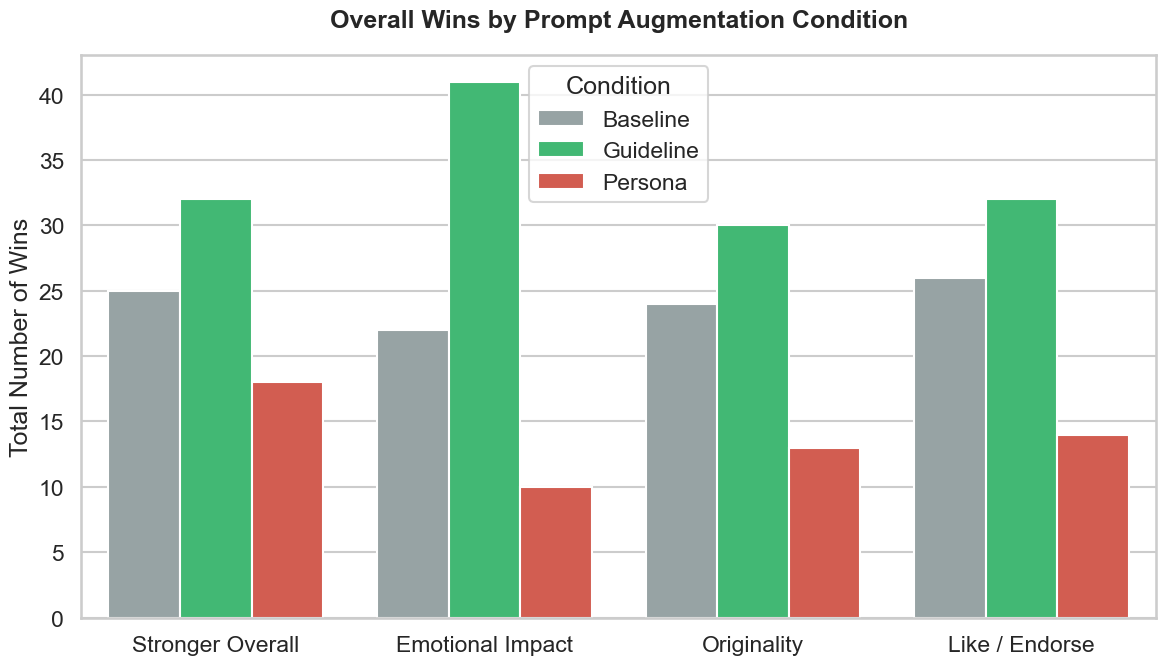

In [8]:
# Overall Win Rates Bar Chart
fig, ax = plt.subplots(figsize=(12, 7))

win_data = []
categories = ['stronger_overall', 'emotional_impact', 'originality', 'like']
labels = ['Stronger Overall', 'Emotional Impact', 'Originality', 'Like / Endorse']

for cat, label in zip(categories, labels):
    col = f"{cat}_selected_condition"
    counts = data[data[col].isin(['Baseline', 'Guideline', 'Persona'])][col].value_counts()
    for cond in ['Baseline', 'Guideline', 'Persona']:
        win_data.append({'Category': label, 'Condition': cond, 'Wins': counts.get(cond, 0)})

df_wins = pd.DataFrame(win_data)

sns.barplot(data=df_wins, x='Category', y='Wins', hue='Condition', palette=palette, ax=ax)
ax.set_title('Overall Wins by Prompt Augmentation Condition', pad=20, fontweight='bold')
ax.set_ylabel('Total Number of Wins')
ax.set_xlabel('')
plt.legend(title='Condition')
plt.tight_layout()
plt.show()

1. The `Guideline` prompt performs best overall across all evaluation criteria, while the Persona prompt performs worst across all metrics.

2. The Baseline and Guideline prompts perform very similarly in overall quality, originality, and likeability, indicating that prompt augmentation does not always lead to better outcomes.

3. It is surprising that the Baseline prompt performs almost as strongly as the Guideline prompt, with only minimal differences in most evaluation dimensions.

4. The most significant improvement from prompt augmentation is observed in emotional impact, where the Guideline prompt clearly outperforms both Baseline and Persona.

5. This shows that prompt guidelines are particularly effective at improving emotional expression, which appears to be the main benefit of prompt augmentation.

6. The effects of prompting are not consistent across all metrics, suggesting that prompt augmentation has a targeted rather than general impact on poetry quality.

7. More complex prompting, such as Persona-based prompts, can reduce perceived quality, while simpler prompts can still produce competitive results.

Overall, prompt design influences poetry generation, but its benefits are selective and primarily improve emotional impact rather than overall quality.

## Head-to-Head Statistics (Pairwise)


In [9]:
# Pairwise comparisons: Calculate Win % and Significance for each pair
from scipy.stats import binomtest

comparisons = ['Baseline_vs_Guideline', 'Baseline_vs_Persona', 'Guideline_vs_Persona']
metrics = ['stronger_overall', 'emotional_impact', 'originality', 'like']

for comp in comparisons:
    print(f"\n{'='*50}\n{comp}\n{'='*50}")
    subset = data[data['comparison_type'] == comp]
    cond_A, cond_B = comp.split('_vs_')
    
    for metric in metrics:
        col = f"{metric}_selected_condition"
        
        # Count explicit wins for A and B (excluding Ties/Both/Neither)
        wins_A = (subset[col] == cond_A).sum()
        wins_B = (subset[col] == cond_B).sum()
        total_decisions = wins_A + wins_B
        
        if total_decisions > 0:
            pct_A = (wins_A / total_decisions) * 100
            pct_B = (wins_B / total_decisions) * 100
            
            # Simple binomial test for significance (Null Hypothesis: p=0.5)
            p_val = binomtest(wins_A, total_decisions, p=0.5, alternative='two-sided').pvalue
            sig = '*' if p_val < 0.05 else ''
            
            print(f"{metric:>20}: {cond_A} ({pct_A:.1f}%) vs {cond_B} ({pct_B:.1f}%) | p={p_val:.3f} {sig}")



Baseline_vs_Guideline
    stronger_overall: Baseline (52.2%) vs Guideline (47.8%) | p=1.000 
    emotional_impact: Baseline (30.4%) vs Guideline (69.6%) | p=0.093 
         originality: Baseline (55.0%) vs Guideline (45.0%) | p=0.824 
                like: Baseline (52.4%) vs Guideline (47.6%) | p=1.000 

Baseline_vs_Persona
    stronger_overall: Baseline (61.9%) vs Persona (38.1%) | p=0.383 
    emotional_impact: Baseline (75.0%) vs Persona (25.0%) | p=0.041 *
         originality: Baseline (72.2%) vs Persona (27.8%) | p=0.096 
                like: Baseline (75.0%) vs Persona (25.0%) | p=0.041 *

Guideline_vs_Persona
    stronger_overall: Guideline (67.7%) vs Persona (32.3%) | p=0.071 
    emotional_impact: Guideline (83.3%) vs Persona (16.7%) | p=0.000 *
         originality: Guideline (72.4%) vs Persona (27.6%) | p=0.024 *
                like: Guideline (71.0%) vs Persona (29.0%) | p=0.029 *


1. Persona prompting is consistently and significantly worse than other methods

2. Guideline prompting improves performance, especially for emotional expression

3. Baseline vs Guideline differences are small → complexity does not guarantee improvement

4. Results show strong directional patterns, but larger samples are needed for confirmation

**This opens a new research direction**

**What is the optimal level of prompt complexity for creative tasks like poetry?**

## Thematic Interactions


--- Win Distribution per Condition by Theme (Raw Counts) ---


stronger_overall_selected_condition,Baseline,Guideline,Persona
theme,,,
Grief,6,12,5
Hope,12,9,5
Longing,7,11,8



--- Win Percentage Distribution by Theme (%) ---


stronger_overall_selected_condition,Baseline,Guideline,Persona
theme,,,
Grief,26.1%,52.2%,21.7%
Hope,46.2%,34.6%,19.2%
Longing,26.9%,42.3%,30.8%



Chi-Square Test of Independence for Theme vs Prompt Strategy: p=0.457 
-> Result: While there are variances, prompt strategy effectiveness does not have a statistically significant dependency on the theme in this sample size.


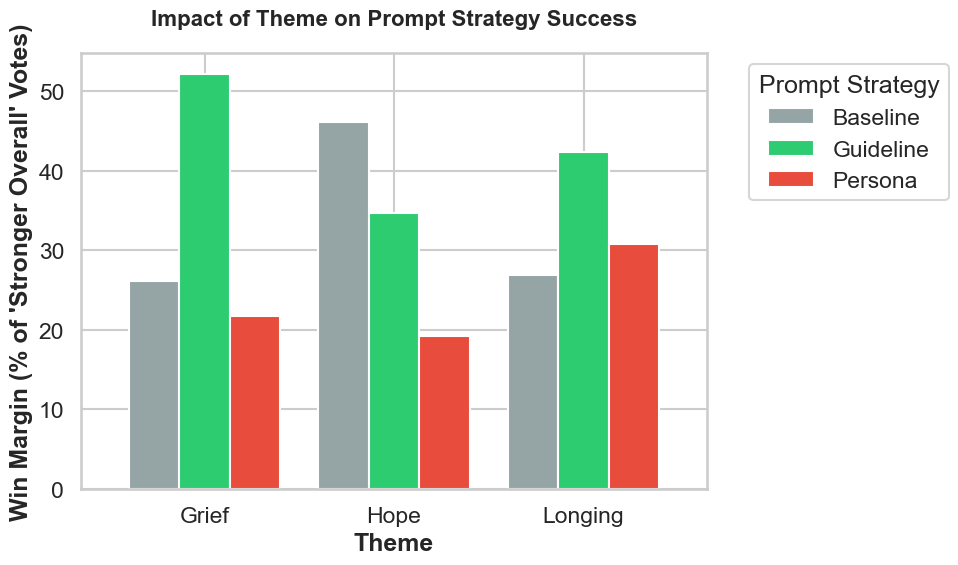

In [10]:
# 4. Thematic Interactions
# Do specific prompt strategies perform better for specific emotional contexts?

palette = {'Baseline': '#95a5a6', 'Guideline': '#2ecc71', 'Persona': '#e74c3c'}

theme_wins = data[data['stronger_overall_selected_condition'].isin(['Baseline', 'Guideline', 'Persona'])]

# Compute win distribution per condition for each theme
crosstab_counts = pd.crosstab(theme_wins['theme'], theme_wins['stronger_overall_selected_condition'])
crosstab_pct = pd.crosstab(theme_wins['theme'], theme_wins['stronger_overall_selected_condition'], normalize='index').mul(100)

print("--- Win Distribution per Condition by Theme (Raw Counts) ---")
display(crosstab_counts)
print("\n--- Win Percentage Distribution by Theme (%) ---")
display(crosstab_pct.round(1).astype(str) + '%')

# Chi-Square Test to check if the difference across themes is statistically significant
chi2, p_val, dof, expected = chi2_contingency(crosstab_counts)
sig = '*' if p_val < 0.05 else ''

print(f"\nChi-Square Test of Independence for Theme vs Prompt Strategy: p={p_val:.3f} {sig}")

if p_val < 0.05:
    print("-> Result: Prompt strategy effectiveness is statistically dependent on the emotional theme!")
else:
    print("-> Result: While there are variances, prompt strategy effectiveness does not have a statistically significant dependency on the theme in this sample size.")

# Which prompt strategy performs best for which emotional context?
fig, ax = plt.subplots(figsize=(10, 6))

crosstab_pct.plot(kind='bar', ax=ax, color=[palette.get(c, '#333') for c in crosstab_pct.columns], width=0.8)

ax.set_title('Impact of Theme on Prompt Strategy Success', pad=20, fontweight='bold', fontsize=16)
ax.set_xlabel('Theme', fontweight='bold')
ax.set_ylabel("Win Margin (% of 'Stronger Overall' Votes)", fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='Prompt Strategy', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

1. The effectiveness of prompt strategies varies across different emotional themes, but these differences are not statistically significant in this sample.

2. For the Grief theme, the Guideline prompt performs best, suggesting that structured prompts help generate stronger poems for emotionally heavy or sensitive topics.

3. For the Hope theme, the Baseline prompt performs best, which is surprising and indicates that simpler prompts may work better for more positive or straightforward emotional contexts.

4. For the Longing theme, the Guideline prompt again performs best, but the Persona prompt performs relatively better here compared to other themes.

5. It is noticeable that the Persona prompt performs particularly poorly for Grief and Hope, but performs comparatively better for Longing, suggesting that persona-based prompting may only be useful in certain emotional contexts.

6. Despite these variations, the statistical test shows that the differences are not significant, meaning we cannot confidently conclude that prompt effectiveness depends on theme based on the current sample size.

7. This suggests that while there are observable patterns, more data is needed to determine whether emotional context truly influences prompt strategy effectiveness.

Overall, prompt strategies may interact with emotional context, but this relationship is not strong enough yet to be considered a reliable effect.

## Human Authorship Perception


In [11]:
# 5. Which condition is most often perceived as human?
human_col = 'human_authorship_selected_condition'

human_counts = data[data[human_col].isin(['Baseline', 'Guideline', 'Persona'])][human_col].value_counts()
print("--- Most Frequently Perceived as Human ---")
print(human_counts)

# Let's see if picking a poem as "Human" correlates with picking it as "Stronger"
human_mask = data[human_col].isin(['Baseline', 'Guideline', 'Persona'])
matching = (data.loc[human_mask, human_col] == data.loc[human_mask, 'stronger_overall_selected_condition']).mean() * 100

# print(f"\nWhen a participant guessed a specific poem was Human, they also selected it as 'Stronger Overall' {matching:.1f}% of the time.")

--- Most Frequently Perceived as Human ---
human_authorship_selected_condition
Guideline    25
Baseline     22
Persona      14
Name: count, dtype: int64


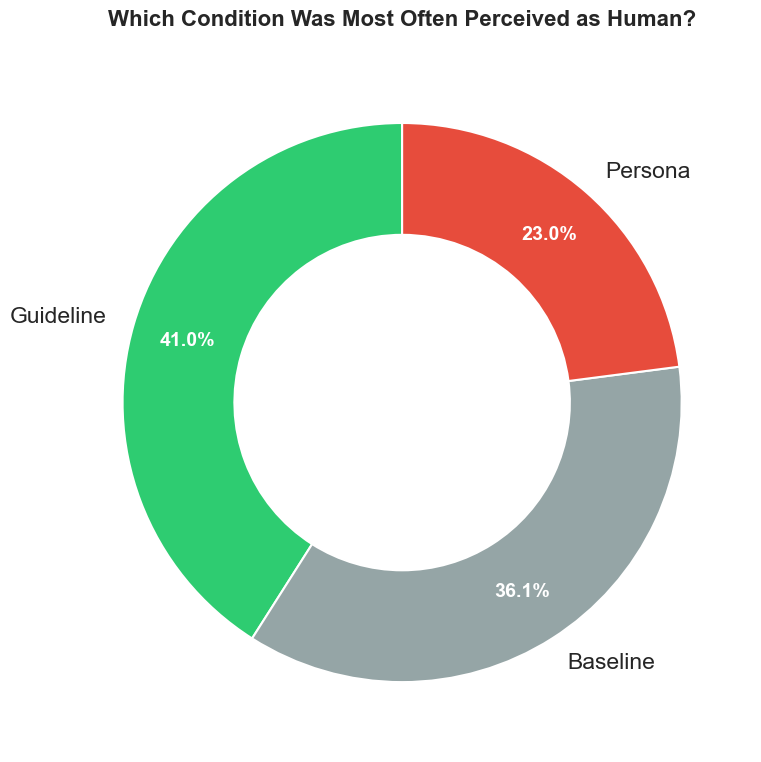

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

human_col = 'human_authorship_selected_condition'
human_counts = data[data[human_col].isin(['Baseline', 'Guideline', 'Persona'])][human_col].value_counts()

colors = [palette.get(x, '#333333') for x in human_counts.index]

wedges, texts, autotexts = ax.pie(human_counts, labels=human_counts.index, autopct='%1.1f%%', 
                                  startangle=90, colors=colors, wedgeprops=dict(width=0.4, edgecolor='w'), pctdistance=0.80)

plt.setp(autotexts, size=14, weight="bold", color="white")
ax.set_title('Which Condition Was Most Often Perceived as Human?', pad=20, fontweight='bold', size=16)

plt.tight_layout()
plt.show()

1. The Baseline prompt is most often perceived as human-written, followed very closely by the Guideline prompt, while the Persona prompt is least often perceived as human.

2. It is surprising that the Baseline prompt slightly outperforms the Guideline prompt in perceived human authorship, despite Guideline performing better in emotional impact.

3. This suggests that simpler prompts may produce poems that feel more natural or authentic to readers.

4. The lower performance of the Persona prompt indicates that adding explicit persona or context may make poems feel less human and more artificial.

5. The small difference between Baseline and Guideline suggests that improving emotional quality does not necessarily increase perceived human-likeness.

6. This reveals that human-likeness and perceived quality are related but not identical, and improving one does not guarantee improvement in the other.


Overall, poems generated with simpler or lightly structured prompts are more likely to be perceived as human than those generated with more complex prompt strategies. The most human-like poems are not necessarily the most engineered ones, and increasing prompt complexity can reduce perceived authenticity.

### Are 'Better' Poems Perceived as Human?
Cross-tabulating Stronger/Liked vs Human Authorship. P(Human | Condition Wins)

P(Condition is perceived as Human | Condition won 'Stronger Overall')


human_authorship_selected_condition,Baseline,Guideline,Persona
stronger_overall_selected_condition,,,
Baseline,73.9%,8.7%,17.4%
Guideline,9.5%,76.2%,14.3%
Persona,25.0%,25.0%,50.0%


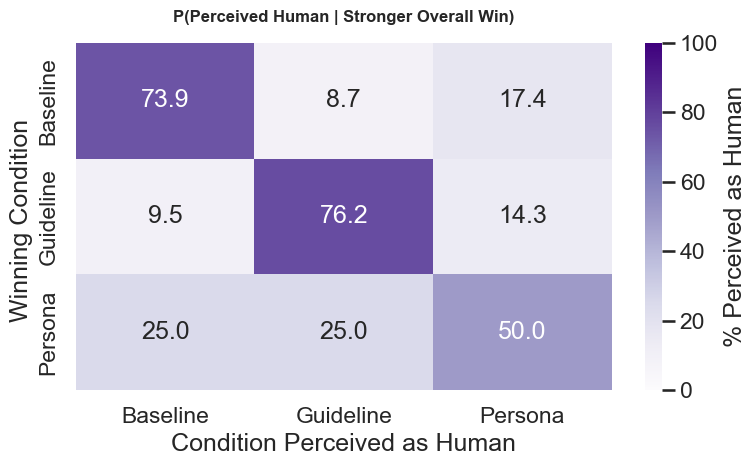

In [13]:
# When a specific condition wins 'Stronger Overall', what is the probability it is also perceived as 'Human'?
# Look only at rows where 'stronger' was an explicit choice (not Tie) and 'human' was an explicit choice
valid_mask = data['stronger_overall_selected_condition'].isin(['Baseline', 'Guideline', 'Persona']) & data['human_authorship_selected_condition'].isin(['Baseline', 'Guideline', 'Persona'])

subset = data[valid_mask]
crosstab = pd.crosstab(subset['stronger_overall_selected_condition'], subset['human_authorship_selected_condition'], normalize='index') * 100

print("P(Condition is perceived as Human | Condition won 'Stronger Overall')")
display(crosstab.round(1).astype(str) + '%')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(crosstab, annot=True, fmt=".1f", cmap="Purples", vmin=0, vmax=100, cbar_kws={'label': '% Perceived as Human'})
ax.set_title("P(Perceived Human | Stronger Overall Win)", pad=15, fontweight='bold', fontsize=12)
ax.set_ylabel("Winning Condition ")
ax.set_xlabel("Condition Perceived as Human")
plt.tight_layout()
plt.show()


1. When a poem generated by a specific condition is judged as the strongest, it is most often also perceived as human-written for that same condition.

2. For the Baseline condition, when it wins as the stronger poem, it is perceived as human-written about 72.7% of the time, indicating a strong alignment between quality and human-likeness.

3. For the Guideline condition, this alignment is also strong, with 68.8% of its winning poems being perceived as human-written.

4. This shows that for both Baseline and Guideline prompts, better-performing poems are generally also seen as more human-like.

5. In contrast, the Persona condition shows a weaker and less consistent relationship, with only 50% alignment when it wins, indicating that even when Persona-generated poems are strong, they are not always perceived as human.

6. It is noticeable that when Baseline or Guideline wins, participants rarely attribute human authorship to a different condition, suggesting that participants are consistent in linking quality with perceived human origin.

7. This suggests that perceived quality and human-likeness are closely related, but this relationship is weaker for more complex prompting strategies like Persona.

Overall, poems that are judged as better are more likely to be perceived as human, but this effect is strongest for simpler or moderately structured prompts. Better poems are generally perceived as more human, but this relationship is strongest for Baseline and Guideline prompts and weaker for Persona prompting.

### Does Participant Expertise Matter?
Do highly familiar readers prefer structural Guidelines more than novices?

In [14]:
print("\nParticipant Familiarity with Poetry:")
print(data.drop_duplicates('sessionId')['familiarity'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


Participant Familiarity with Poetry:
familiarity
very_familiar        60.0%
somewhat_familiar    30.0%
not_very_familiar    10.0%
Name: proportion, dtype: str


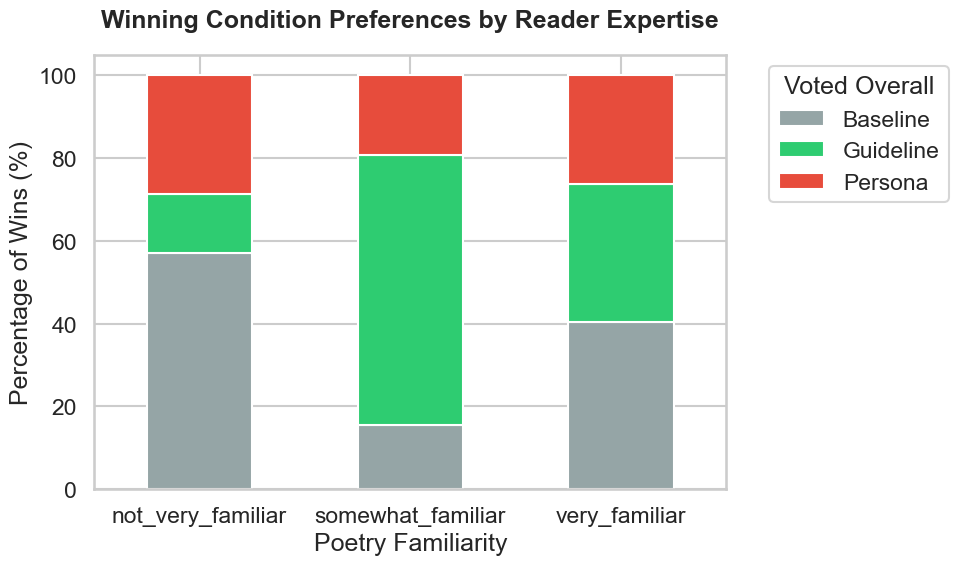

In [15]:
# Let's break down 'Stronger Overall' wins by the participant's self-reported familiarity
fam_wins = data[data['stronger_overall_selected_condition'].isin(['Baseline', 'Guideline', 'Persona'])]

fam_cross = pd.crosstab(fam_wins['familiarity'], fam_wins['stronger_overall_selected_condition'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
fam_cross.plot(kind='bar', stacked=True, color=[palette[c] for c in fam_cross.columns], ax=ax)

ax.set_title('Winning Condition Preferences by Reader Expertise', pad=20, fontweight='bold')
ax.set_ylabel('Percentage of Wins (%)')
ax.set_xlabel('Poetry Familiarity')
plt.xticks(rotation=0)
plt.legend(title='Voted Overall', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [16]:
display(fam_cross.round(1).astype(str) + '%')

stronger_overall_selected_condition,Baseline,Guideline,Persona
familiarity,,,
not_very_familiar,57.1%,14.3%,28.6%
somewhat_familiar,15.4%,65.4%,19.2%
very_familiar,40.5%,33.3%,26.2%


1. Participant expertise appears to influence how different prompt strategies are perceived, with noticeable differences across familiarity levels.

2. Participants who are not very familiar with poetry strongly prefer the Baseline prompt, suggesting that simpler and more direct poems are easier to understand and evaluate for less experienced readers.

3. Participants who are somewhat familiar with poetry show a strong preference for the Guideline prompt, indicating that structured prompts may appeal more to readers with moderate familiarity.

4. Participants who are very familiar with poetry show a more balanced preference across Baseline and Guideline, with a slight preference for Baseline, suggesting that experienced readers do not strongly favor additional prompt structure.

5. It is surprising that highly familiar readers do not show a clear preference for Guideline prompting, which might be expected to produce more refined or structured poetry.

6. This suggests that experienced readers may value naturalness and subtlety over explicit structure, which could explain why Baseline performs competitively.

7. The Persona prompt performs relatively consistently across all groups but never becomes the preferred option, indicating that its limitations are not dependent on reader expertise.

Overall, the effectiveness of prompt strategies is influenced by reader familiarity, but simpler prompts remain competitive even among experienced readers. Reader expertise shapes evaluation preferences, but simpler prompts remain strong across all groups, while more complex prompting does not gain advantage even with experienced readers.

### Metric Correlation Heatmap
If a poem wins 'Emotional Impact', does it also win 'Like / Endorse'?


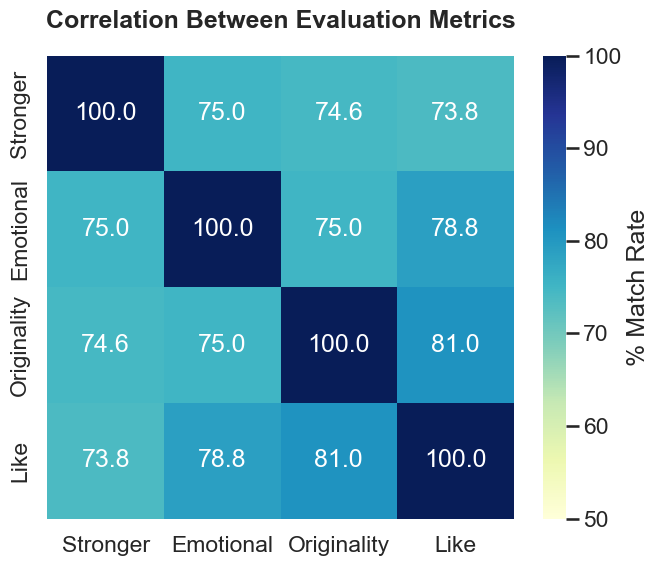

In [17]:
# Let's compute how often the SAME poem won different categories in the same comparison
cats = ['stronger_overall', 'emotional_impact', 'originality', 'like']
labels = ['Stronger', 'Emotional', 'Originality', 'Like']
corr_matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)

for i, cat1 in enumerate(cats):
    for j, cat2 in enumerate(cats):
        col1 = f"{cat1}_selected_poem_id"
        col2 = f"{cat2}_selected_poem_id"
        
        # We only look at rows where an explicit poem was chosen for BOTH questions (A or B)
        valid_mask = data[col1].str.contains('-') & data[col2].str.contains('-')
        
        if valid_mask.sum() > 0:
            # Percentage of times they picked the exact same poem for both categories
            match_pct = (data.loc[valid_mask, col1] == data.loc[valid_mask, col2]).mean() * 100
            corr_matrix.iloc[i, j] = match_pct

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap="YlGnBu", vmin=50, vmax=100, 
            cbar_kws={'label': '% Match Rate'}, ax=ax)

ax.set_title('Correlation Between Evaluation Metrics', pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

1. When a poem is judged as better, it is usually also seen as more human, especially for Baseline and Guideline prompts.

2. This shows that people tend to associate good poetry with human writing, meaning quality and human-likeness are closely linked.

3. However, this connection is weaker for Persona prompting, meaning even when those poems are good, they do not always feel human.

Overall, simpler prompts (Baseline and Guideline) produce poems that are both better and more human-like, while more complex prompts break this connection.

## Notes

- This experiment shows that prompt augmentation does not universally improve AI-generated poetry, but instead has selective effects on specific dimensions of quality.

- It demonstrates that guideline-based prompting significantly improves emotional impact, but does not consistently improve overall quality, originality, or user preference compared to simple prompts.

- It introduces a new evaluation perspective by linking poem quality with perceived human authorship, showing that better poems are often perceived as more human.

- It reveals that simpler prompts (Baseline) can produce poems that are both high-quality and more human-like, challenging the assumption that more complex prompts lead to better outputs.


Existing research, from literature reviews focuses heavily on improving generation, but does not sufficiently examine how different prompt strategies affect human perception of quality and authorship. Most studies treat evaluation metrics (emotion, originality, preference) as independent, while this experiment shows that humans evaluate poetry holistically.

Prior work does not explore the relationship between:
prompt strategy → perceived quality → perceived human-likeness
There is limited investigation into whether increasing prompt complexity can negatively impact perceived quality, which this study highlights.